In [1]:
import numpy as np
import matplotlib.pyplot as plt
import millefeuille as mf

state = mf.State.load(
    "databases/Gorgon_MF_DB_Gorgon_MF_iceburner_final_week.db"
)

surrogate = mf.MultiOutputRandomForestSurrogate(
    n_outputs=len(state.Y_names),
    verbose=True,
)

surrogate.fit(state)

ModuleNotFoundError: No module named 'millefeuille'

In [ ]:
X_train = np.asarray(state.Xs, dtype=float)

# A real, central point from the training distribution
X_anchor = np.median(X_train, axis=0)

r_idx = state.X_names.index("f_R_outer")

R_scan = np.linspace(
    np.quantile(X_train[:, r_idx], 0.05),
    np.quantile(X_train[:, r_idx], 0.95),
    100,
)

X_pred = np.repeat(X_anchor[None, :], len(R_scan), axis=0)
X_pred[:, r_idx] = R_scan

Y_pred = surrogate.predict(state, X_pred)

In [ ]:
print(state.X_names)

['f_laser', 'f_R_outer', 'f_Pi', 'f_Be', 'f_rho', 'current']


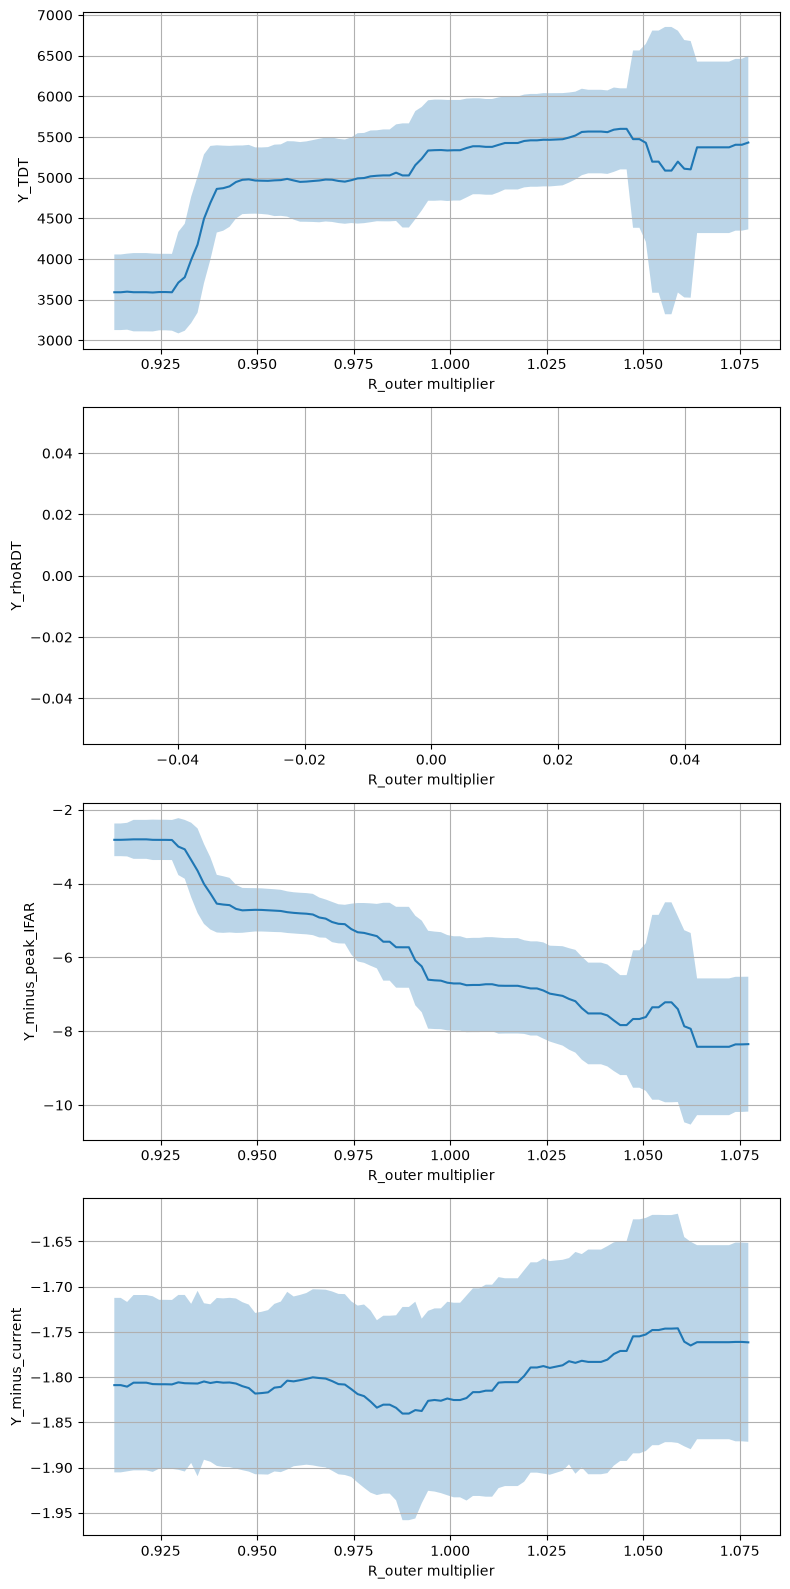

In [ ]:
Y_mean = np.asarray(Y_pred["mean"])
Y_std = np.asarray(Y_pred["std"])


fig, axes = plt.subplots(
    len(state.Y_names),
    1,
    figsize=(8, 4 * len(state.Y_names))
)

for i, name in enumerate(state.Y_names):
    mean = Y_mean[:, i]
    std = Y_std[:, i]

    axes[i].plot(R_scan, mean)
    axes[i].fill_between(
        R_scan,
        mean - std,
        mean + std,
        alpha=0.3
    )

    axes[i].set_xlabel("R_outer multiplier")
    axes[i].set_ylabel(name)
    axes[i].grid()

plt.tight_layout()
plt.show()